# Ray Sources

The NSQ engine provides three source types that cover most real-world scenarios:

| Class | Geometry | Typical use |
|---|---|---|
| `PointSource` | Single point, cone emission | LED die, lamp filament |
| `CollimatedSource` | Circular disk, parallel rays | Laser beam, far-field source |
| `ExtendedSource` | Rectangular area, cosine emission | Display panel, diffuse emitter |

All sources require a `Spectrum` object (wavelengths in **µm**) and accept a
`total_flux` in watts. Their position and orientation are set by a
`CoordinateSystem`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    PointSourceConfig, CollimatedSourceConfig, ExtendedSourceConfig,
    IrradianceDetectorConfig, RayDatabaseConfig,
)


## 1. Spectra

### Monochromatic spectrum

A single wavelength — the fastest and simplest option:

In [2]:
spec_green = Spectrum.monochromatic(0.55)   # 550 nm
spec_red   = Spectrum.monochromatic(0.633)  # 633 nm HeNe laser
spec_blue  = Spectrum.monochromatic(0.45)   # 450 nm

### Broadband spectrum

Pass arrays of wavelengths (µm) and relative spectral weights. The weights are
normalised internally and used for Monte Carlo sampling — so only their ratios
matter, not their absolute values:

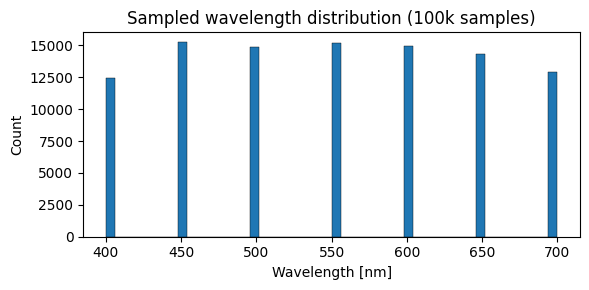

In [3]:
# Rough D65 visible spectrum sampled at 7 wavelengths
spec_white = Spectrum(
    wavelengths=np.array([0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]),
    weights=np.array([0.82, 1.04, 1.00, 1.01, 1.00, 0.95, 0.88]),
)

# Sample 8 wavelengths from the spectrum and check the distribution
rng = np.random.default_rng(0)
samples = spec_white.sample(100_000, rng)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(samples * 1000, bins=50, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Count')
ax.set_title('Sampled wavelength distribution (100k samples)')
plt.tight_layout()
plt.show()

## 2. PointSource

A point emitter with configurable solid-angle cone:
- `half_angle_deg=90` → hemisphere (default)
- `half_angle_deg=180` → full sphere (isotropic)
- `half_angle_deg=<small>` → narrow forward cone

The `CoordinateSystem` controls the cone axis: the source emits along the
local `+z` direction.

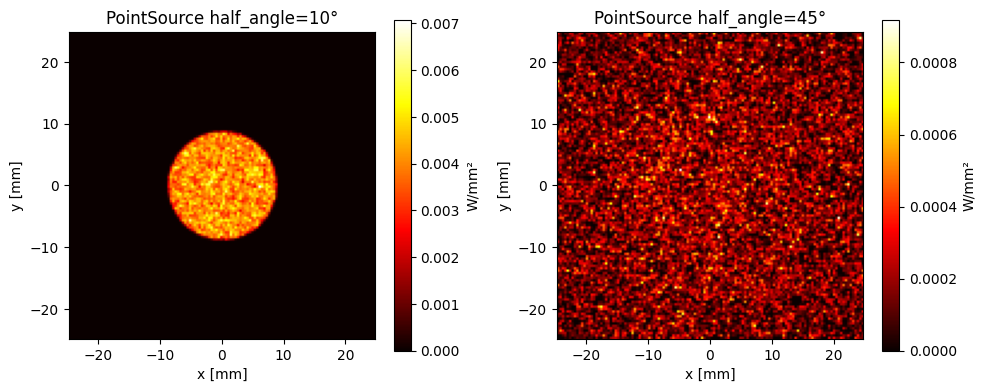

In [4]:
def irradiance_from_point_source(half_angle_deg, num_rays=30_000):
    scene = NSQScene()
    scene.add_source(
        'S', CoordinateSystem(z=0),
        PointSourceConfig(spectrum=spec_green, total_flux=1.0,
                          half_angle_deg=half_angle_deg),
    )
    scene.add_detector(
        'D', CoordinateSystem(z=50),
        IrradianceDetectorConfig(width=50, height=50, num_pixels_x=128, num_pixels_y=128),
    )
    result = scene.trace(num_rays=num_rays, seed=0)
    return result.detectors['D']

narrow = irradiance_from_point_source(10)
wide   = irradiance_from_point_source(45)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, irr, angle in zip(axes, [narrow, wide], [10, 45]):
    im = ax.imshow(irr.irradiance, origin='lower',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                            irr.y_coords[0], irr.y_coords[-1]],
                   cmap='hot', aspect='equal')
    plt.colorbar(im, ax=ax, label='W/mm²')
    ax.set_title(f'PointSource half_angle={angle}°')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.tight_layout()
plt.show()

## 3. CollimatedSource

Emits a parallel beam from a circular aperture. Useful for modelling a laser
or a distant (infinitely far) source.

Two spatial profiles are available:
- `profile='tophat'` — uniform irradiance across the beam
- `profile='gaussian'` — Gaussian irradiance profile

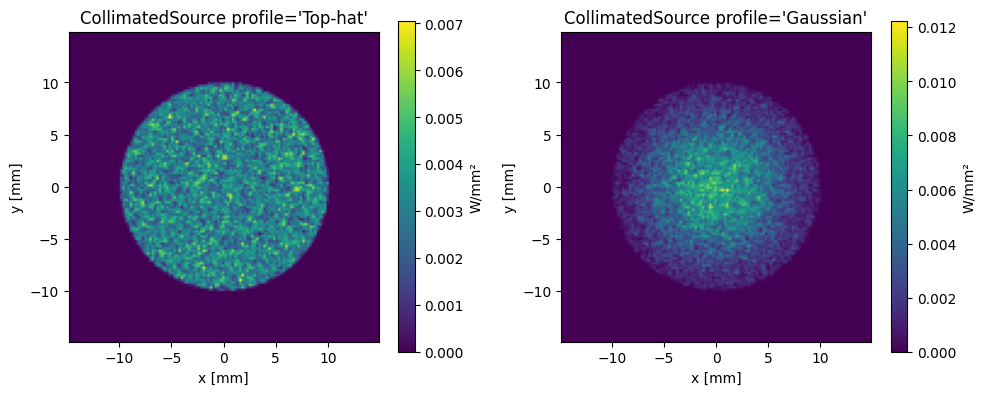

In [5]:
def irradiance_from_collimated(profile, aperture_radius=10, num_rays=30_000):
    scene = NSQScene()
    scene.add_source(
        'S', CoordinateSystem(z=0),
        CollimatedSourceConfig(
            spectrum=spec_green, total_flux=1.0,
            aperture_radius=aperture_radius, profile=profile,
        ),
    )
    scene.add_detector(
        'D', CoordinateSystem(z=50),
        IrradianceDetectorConfig(width=30, height=30, num_pixels_x=128, num_pixels_y=128),
    )
    result = scene.trace(num_rays=num_rays, seed=0)
    return result.detectors['D']

tophat   = irradiance_from_collimated('tophat')
gaussian = irradiance_from_collimated('gaussian')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, irr, title in zip(axes, [tophat, gaussian], ['Top-hat', 'Gaussian']):
    im = ax.imshow(irr.irradiance, origin='lower',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                            irr.y_coords[0], irr.y_coords[-1]],
                   cmap='viridis', aspect='equal')
    plt.colorbar(im, ax=ax, label='W/mm²')
    ax.set_title(f'CollimatedSource profile={title!r}')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.tight_layout()
plt.show()

## 4. ExtendedSource

An area emitter with Lambertian (cosine-weighted) emission. Each ray is
launched from a random point on the rectangular surface `width × height`
and directed within `half_angle_deg` of the local `+z` axis.

This is useful for modelling display panels, diffuse luminaires, or
area light sources.

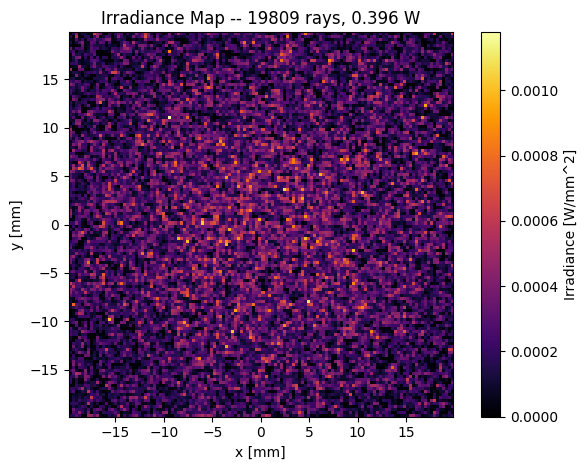

Rays on detector: 19,809  |  Flux: 0.3962 W


In [6]:
scene = NSQScene()

# 10 x 5 mm rectangular source, 60-degree emission cone
scene.add_source(
    'S', CoordinateSystem(z=0),
    ExtendedSourceConfig(
        spectrum=spec_green, total_flux=1.0,
        width=10, height=5, half_angle_deg=60,
    ),
)
scene.add_detector(
    'D', CoordinateSystem(z=30),
    IrradianceDetectorConfig(width=40, height=40, num_pixels_x=128, num_pixels_y=128),
)
result = scene.trace(num_rays=50_000, seed=0)
irr = result.detectors['D']

fig = irr.plot(cmap='inferno')
plt.tight_layout()
plt.show()

print(f"Rays on detector: {irr.num_rays_hit:,}  |  Flux: {irr.total_flux:.4f} W")

## 5. Broadband Source Example

Using the `spec_white` spectrum defined earlier, launch a broadband point source
and verify the wavelength distribution on the detector via a `RayDatabaseDetector`:

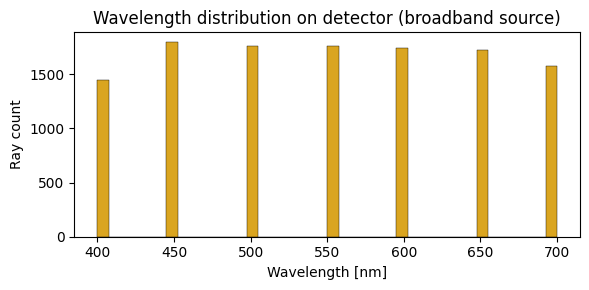

In [7]:
scene2 = NSQScene()
scene2.add_source(
    'S', CoordinateSystem(z=0),
    PointSourceConfig(spectrum=spec_white, total_flux=1.0, half_angle_deg=30),
)

# A RayDatabaseDetector stores every hitting ray as a full phase-space record.
scene2.add_detector(
    'RDB', CoordinateSystem(z=40),
    RayDatabaseConfig(width=30, height=30),
)

result2 = scene2.trace(num_rays=20_000, seed=1)
db = result2.detectors['RDB']

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(db.wavelength * 1000, bins=40, color='goldenrod', edgecolor='k', linewidth=0.3)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Ray count')
ax.set_title('Wavelength distribution on detector (broadband source)')
plt.tight_layout()
plt.show()


## Summary

- All wavelengths are in **µm** throughout the NSQ engine
- `Spectrum.monochromatic(wl_um)` for single-wavelength simulations
- `Spectrum(wavelengths, weights)` for polychromatic simulations
- `PointSource` — cone emitter; `half_angle_deg` controls the beam spread
- `CollimatedSource` — parallel beam; `aperture_radius` sets the beam size
- `ExtendedSource` — area emitter with Lambertian distribution
- Multiple sources can be added to a single scene